# Diabetes prediction: random forest

## Notebook set-up

In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

import configuration as config
import functions as funcs

## 1. Data preparation

### 1.1. Load data from disk

In [2]:
# with open(config.DATA_FILE, 'rb') as input_file:
#     dataset=pickle.load(input_file)

# training_df=dataset['training']
# testing_df=dataset['testing']

dataset = funcs.load_data('https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv')

### 1.2. Inspect

In [3]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Baseline model

In [4]:
# Your code here
X = dataset.drop('Outcome', axis=1)
y = dataset['Outcome']

X_train, X_test, y_train, y_test = funcs.train_test_split_data(X, y)

## 4. Hyperparameter optimization

### 4.1. Hyperparameter grid search

In [5]:
# Your code here
param_grid_rf = {
    'n_estimators' : [50, 10, 200],
    'max_depth' : [None, 3, 5, 7],
    'min_samples_split' : [2, 10],
    'min_samples_leaf' : [1, 5],
    'max_features' : ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search_rf.fit(X_train, y_train)

# Best hyperparameters and cross-validation score
print("Best Hyperparameters for RandomForest:", grid_search_rf.best_params_)
print("Best Cross-Validation Accuracy: {:.4f}".format(grid_search_rf.best_score_))


Best Hyperparameters for RandomForest: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.7834


### 4.2. Hyperparameter optimization results

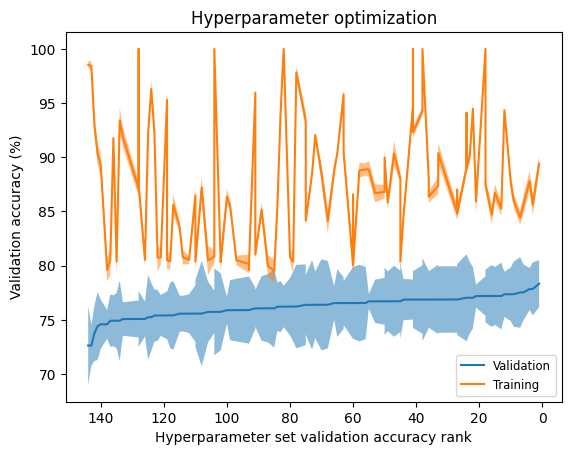

In [6]:
funcs.plot_cross_validation(grid_search_rf)

### 4.3. Cross-validation of optimized model

In [11]:
# Your code here
best_rf = grid_search_rf.best_estimator_

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy: {:.4f} +/- {:.4f}".format(cv_scores.mean(), cv_scores.std()))

Cross-Validation Accuracy Scores: [0.76422764 0.80487805 0.75609756 0.7804878  0.81147541]
Mean CV Accuracy: 0.7834 +/- 0.0218


## 5. Evaluation

### 5.1. Model comparison

Confusion Matrix:
[[86 14]
 [22 32]]
Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.86      0.83       100
    Diabetic       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154

ROC AUC: 0.82


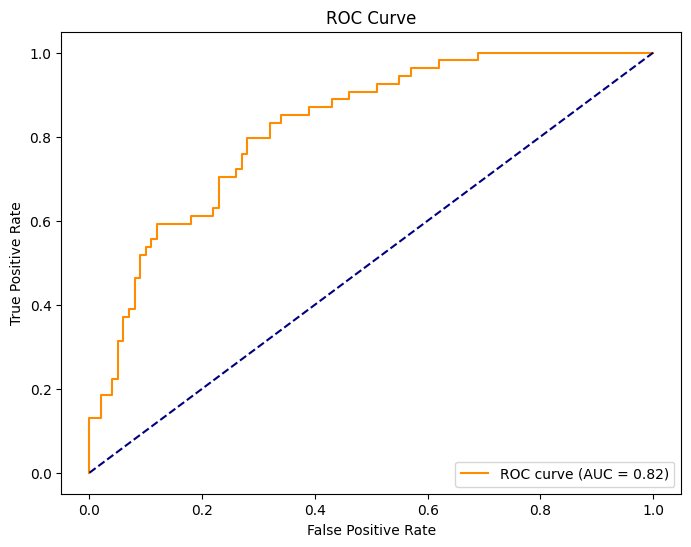

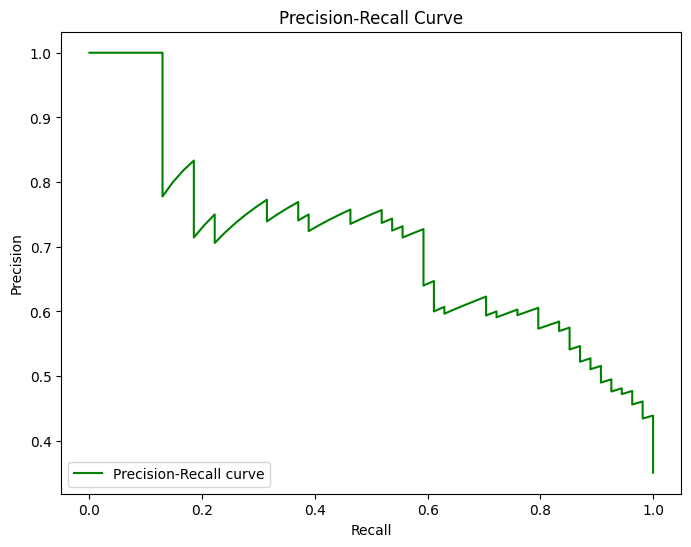

In [12]:
best_rf = grid_search_rf.best_estimator_
cm_rf, report_rf, roc_auc_rf = funcs.evaluate_model(best_rf, X_test, y_test)

In [14]:
# Your code here
# Predict on the test set with the optimized model
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Generate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
specificity_rf = tn / (tn + fp)

print("Random Forest Confusion Matrix:")
print(cm_rf)
print(f"Specificity: {specificity_rf:.2f}")


Random Forest Confusion Matrix:
[[86 14]
 [22 32]]
Specificity: 0.86


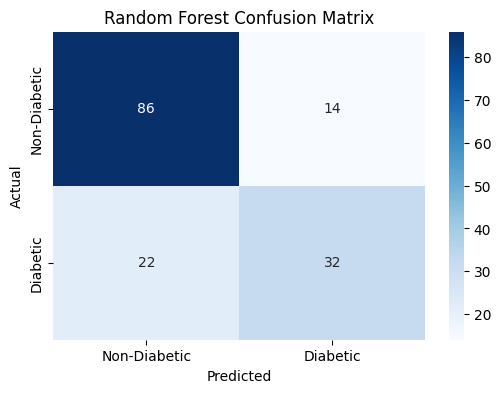

In [9]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.2. Test set performance

In [ ]:
# Your code here

## 6. Save

### 6.1. Optimized hyperparameters

In [ ]:
with open(config.RANDOM_FOREST_HYPERPARAMETERS, 'wb') as output_file:
    pickle.dump(hyperparameters, output_file)

### 6.2. Model

In [ ]:
with open(config.RANDOM_FOREST_MODEL, 'wb') as output_file:
    pickle.dump(model, output_file)